In [26]:
import torch
import matplotlib.pyplot as plt
from torch import nn, optim

torch.manual_seed(42)
X = torch.linspace(-3, 3, 300).reshape(-1, 1)
y = torch.sin(X) + torch.randn(300, 1) * 0.15

# Shuffle indices
indices = torch.randperm(300)
train_idx = indices[:210]
val_idx = indices[210:255]
test_idx = indices[255:]

# Split into train/validate/test
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

model = nn.Sequential(
    nn.Linear(1, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
)

opt = optim.Adam(model.parameters(), lr=0.01)
loss_ft = nn.MSELoss()

train_losses = []
val_losses = []

# I first ran 3000 epochs, but noticed that the loss pretty much converged at
# 50 epochs, so I updated the value here
for epoch in range(50):
  # Train the model (with backward)
  y_pred_train = model(X_train)
  loss_train = loss_ft(y_pred_train, y_train)
  loss_train.backward()
  opt.step()
  opt.zero_grad()

  # Test out on validation set (without backward)
  with torch.no_grad():
    y_pred_val = model(X_val)
    loss_val = loss_ft(y_pred_val, y_val)

  if epoch % 5 == 0 or epoch == 49:
    print(f"Epoch {epoch}")
    print(f"Loss of training set: {loss_train:.4f}")
    print(f"Loss of validation set: {loss_val:.4f}")


  train_losses.append(loss_train.item())
  val_losses.append(loss_val.item())

Epoch 0
Loss of training set: 0.5379
Loss of validation set: 0.8049
Epoch 5
Loss of training set: 0.2574
Loss of validation set: 0.1515
Epoch 10
Loss of training set: 0.1676
Loss of validation set: 0.1411
Epoch 15
Loss of training set: 0.1092
Loss of validation set: 0.0891
Epoch 20
Loss of training set: 0.0735
Loss of validation set: 0.0482
Epoch 25
Loss of training set: 0.0628
Loss of validation set: 0.0368
Epoch 30
Loss of training set: 0.0512
Loss of validation set: 0.0392
Epoch 35
Loss of training set: 0.0415
Loss of validation set: 0.0284
Epoch 40
Loss of training set: 0.0344
Loss of validation set: 0.0241
Epoch 45
Loss of training set: 0.0290
Loss of validation set: 0.0211
Epoch 49
Loss of training set: 0.0268
Loss of validation set: 0.0199


In [28]:
# Find the best and worst epochs and losses
best_epoch = val_losses.index(min(val_losses))
print(f"Best epoch: {best_epoch}, Val loss: {min(val_losses):.4f}")

worst_epoch = val_losses.index(max(val_losses))
print(f"Worst epoch: {worst_epoch}, Val loss: {max(val_losses):.4f}")

Best epoch: 49, Val loss: 0.0199
Worst epoch: 0, Val loss: 0.8049


In [31]:
# Check train/val/test losses
train_loss = loss_ft(model(X_train), y_train)
val_loss = loss_ft(model(X_val), y_val)

print(f"Train loss: {train_loss.item():.4f}")
print(f"Validation loss: {val_loss.item():.4f}")

with torch.no_grad():
    test_loss = loss_ft(model(X_test), y_test)
    print(f"Test loss: {test_loss.item():.4f}")

Train loss: 0.0262
Validation loss: 0.0199
Test loss: 0.0242


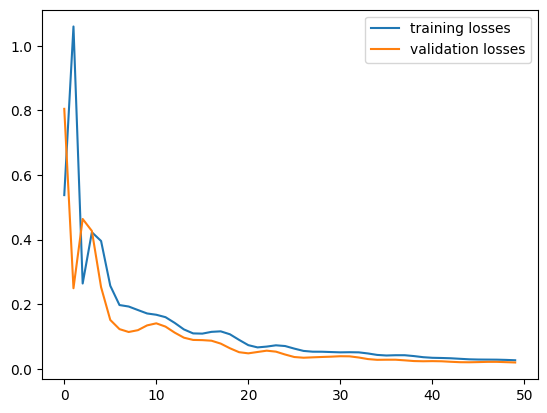

In [30]:
# Plot the results
plt.plot(train_losses, label='training losses')
plt.plot(val_losses, label='validation losses')
plt.legend()
plt.show()